In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


In [3]:
data_dir

'.\\datasets\\flower_photos'

In [5]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

WindowsPath('datasets/flower_photos')

In [8]:
list(data_dir.glob('**/*.jpg'))

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/102841525_bd6628ae3c.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/1031799732_e7f4008c03.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10391248763_1d16681106_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10437754174_22ec990b77_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10437770546_8bb6f7bdd3_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10437929963_bc13eebe0c.jpg'),
 WindowsPath('datasets/flower_photos

In [9]:
image_count = len(list(data_dir.glob('**/*.jpg')))
print(image_count)

3670


In [12]:
roses = list(data_dir.glob('*/roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

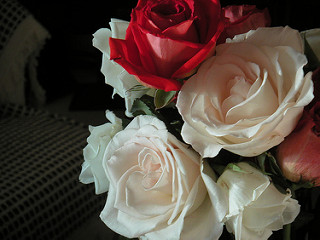

In [13]:
PIL.Image.open(str(roses[1]))

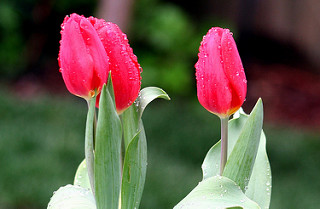

In [14]:
tulips = list(data_dir.glob('*/tulips/*'))
PIL.Image.open(str(tulips[0]))

In [15]:
flowers_images_dict = {
    'roses': list(data_dir.glob('*/roses/*')),
    'daisy': list(data_dir.glob('*/daisy/*')),
    'dandelion': list(data_dir.glob('*/dandelion/*')),
    'sunflowers': list(data_dir.glob('*/sunflowers/*')),
    'tulips': list(data_dir.glob('*/tulips/*')),
}

In [16]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [17]:
flowers_images_dict['roses'][:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

In [18]:
str(flowers_images_dict['roses'][0])

'datasets\\flower_photos\\flower_photos\\roses\\10090824183_d02c613f10_m.jpg'

In [19]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [20]:
img.shape

(240, 179, 3)

In [21]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [22]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [23]:
X = np.array(X)
y = np.array(y)

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [26]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [27]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 30s 298ms/step - accuracy: 0.4262 - loss: 1.3148
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 238ms/step - accuracy: 0.6192 - loss: 0.9694
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.6911 - loss: 0.7983
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.7722 - loss: 0.6147
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 241ms/step - accuracy: 0.8517 - loss: 0.4216
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 243ms/step - accuracy: 0.9201 - loss: 0.2513
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.9542 - loss: 0.1391
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.9727 - loss: 0.0983
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 53s 623ms/step - accuracy: 0.9898 - loss: 0.0451
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 365ms/step - accuracy: 0.9935 - loss: 0.0303
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 391ms/step - accuracy: 0.9985 - loss: 0.0162
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 3

In [28]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6209 - loss: 1.6052


[1.6052085161209106, 0.6209150552749634]

In [29]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step


array([[ -0.6682661 ,  11.054662  ,  -1.2178037 , -15.0520735 ,
         -3.3424776 ],
       [  4.433243  ,  -5.576951  , -15.695166  , -11.136157  ,
         10.820697  ],
       [ -4.9640846 ,   2.9329963 ,   3.2998307 ,  -5.9278703 ,
         -1.2681246 ],
       ...,
       [  1.5746125 ,  -1.9986665 ,  -6.412921  ,   1.8727913 ,
          1.2197031 ],
       [  4.132024  ,   2.059924  ,  -4.976054  ,  -7.758009  ,
          0.16182214],
       [  0.12559873,  -5.7230606 ,   0.08920214,   2.8505337 ,
          0.9626726 ]], shape=(918, 5), dtype=float32)

In [30]:
score = tf.nn.softmax(predictions[0])

In [31]:
np.argmax(score)

np.int64(1)

In [32]:
y_test[0]


np.int64(1)

In [36]:
img_height = 180  # Example height - adjust to your actual image size
img_width = 180   # Example width - adjust to your actual image size



data_augmentation = keras.Sequential(
  [
    # Changed from layers.experimental.preprocessing to keras.layers
    keras.layers.RandomFlip("horizontal", 
                           input_shape=(img_height, 
                                      img_width,
                                      3)),
    # Updated import paths for all preprocessing layers
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1),
  ]
)

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


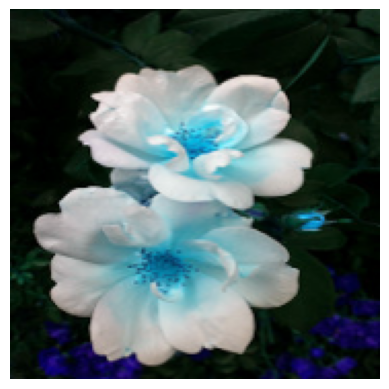

In [37]:
plt.axis('off')
plt.imshow(X[0])

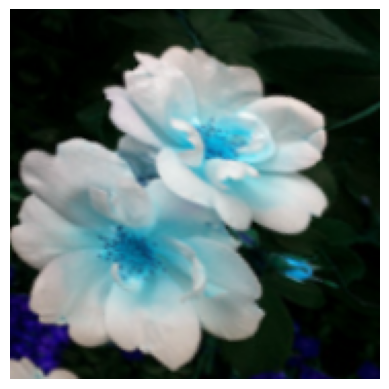

In [38]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))

In [39]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)   

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 55s 433ms/step - accuracy: 0.3957 - loss: 1.3616
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 355ms/step - accuracy: 0.5621 - loss: 1.0843
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 357ms/step - accuracy: 0.6355 - loss: 0.9460
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 32s 373ms/step - accuracy: 0.6624 - loss: 0.8621
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 351ms/step - accuracy: 0.6839 - loss: 0.8021
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 340ms/step - accuracy: 0.7086 - loss: 0.7577
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 28s 329ms/step - accuracy: 0.7224 - loss: 0.7183
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 30s 345ms/step - accuracy: 0.7431 - loss: 0.6759
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 340ms/step - accuracy: 0.7435 - loss: 0.6562
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 337ms/step - accuracy: 0.7605 - loss: 0.6323
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 333ms/step - accuracy: 0.7678 - loss: 0.5966
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 41

In [40]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.7288 - loss: 0.9880


[0.9879651069641113, 0.7287581562995911]